In [54]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor

In [55]:
seed = 42

root_path = "/home/stefan/ioai-prep/kits/dataset-c45484f7-c672-4798-afe7-af14608c2efa"

# Data

In [56]:
df = pd.read_csv(f"{root_path}/train.csv")
df_train = df.drop(["SampleID", "temperature"], axis=1)
y = df["temperature"]

(array([11., 36., 60., 86., 82., 78., 66., 57., 21.,  3.]),
 array([-10.32 ,  -6.346,  -2.372,   1.602,   5.576,   9.55 ,  13.524,
         17.498,  21.472,  25.446,  29.42 ]),
 <BarContainer object of 10 artists>)

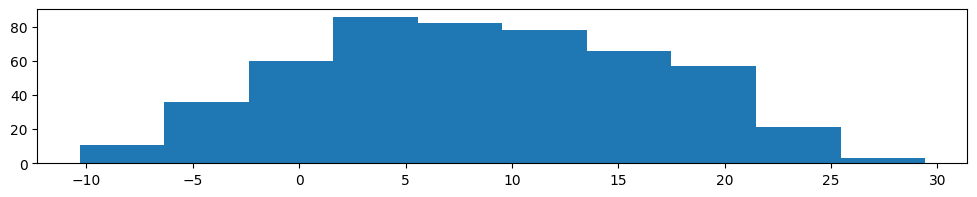

In [57]:
plt.figure(figsize=(12, 2))
plt.hist(y)

# Model

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    df_train, y, test_size=0.2, random_state=seed
)

In [59]:
def evaluate(model):
    cv = cross_val_score(
        model, X_train, y_train, scoring="neg_root_mean_squared_error", cv=3, n_jobs=-1
    )
    cv_score = -(cv.mean() - cv.std())

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    score = root_mean_squared_error(y_test, preds)

    return cv_score, score

In [60]:
ridge = Pipeline(steps=[("poly", PolynomialFeatures()), ("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))])
evaluate(ridge)

(np.float64(2.930569837052843), 2.6606436244199534)

In [110]:
xgb = Pipeline(
    steps=[
        ("poly", PolynomialFeatures(degree=3)),
        ("scaler", StandardScaler()),
        ("model", XGBRegressor(n_estimators=300, max_depth=2, random_state=seed, n_jobs=-1)),
    ]
)

evaluate(xgb)

(np.float64(2.305177806013468), 2.3586962584766247)

In [111]:
model = xgb
model.fit(df_train, y)

Pipeline(steps=[('poly', PolynomialFeatures(degree=3)),
                ('scaler', StandardScaler()),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=2, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=300, n_jobs=-1,
                              num_parallel_tree=None, ...))])

# Submission

In [112]:
df_test = pd.read_csv(f"{root_path}/test.csv")
submission = df_test[["SampleID"]]

df_test = df_test.drop(["SampleID"], axis=1)

In [113]:
submission["temperature"] = model.predict(df_test)
submission.head()

,SampleID,temperature
0,1001,0.126611
1,1002,7.436849
2,1003,17.480282
3,1004,-0.327294
4,1005,6.119393


In [114]:
submission.to_csv(f"{root_path}/submission.csv", index=False)